In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torchvision.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Используем устройство: cuda


Класс kgo_full:  1126 изображений
Класс kgo_empty: 1046 изображений
Соотношение full/empty: 1.08:1


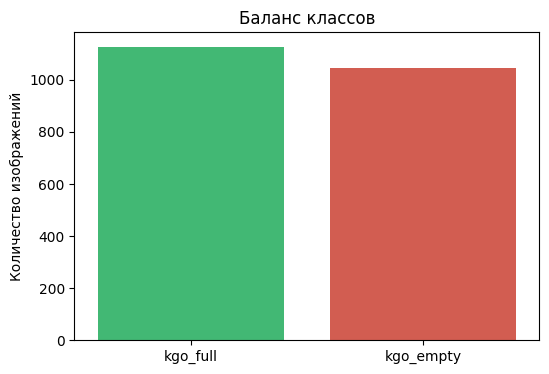

In [ ]:
data_dir = Path("cropped")

full_count = len(list(data_dir.glob("kgo_full/*.jpg")))
empty_count = len(list(data_dir.glob("kgo_empty/*.jpg")))

print(f"Класс kgo_full:  {full_count} изображений")
print(f"Класс kgo_empty: {empty_count} изображений")
print(f"Соотношение full/empty: {full_count/empty_count:.2f}:1")

plt.figure(figsize=(6,4))
sns.barplot(x=['kgo_full', 'kgo_empty'], y=[full_count, empty_count], palette=['#2ecc71', '#e74c3c'])
plt.title('Баланс классов')
plt.ylabel('Количество изображений')
plt.show()

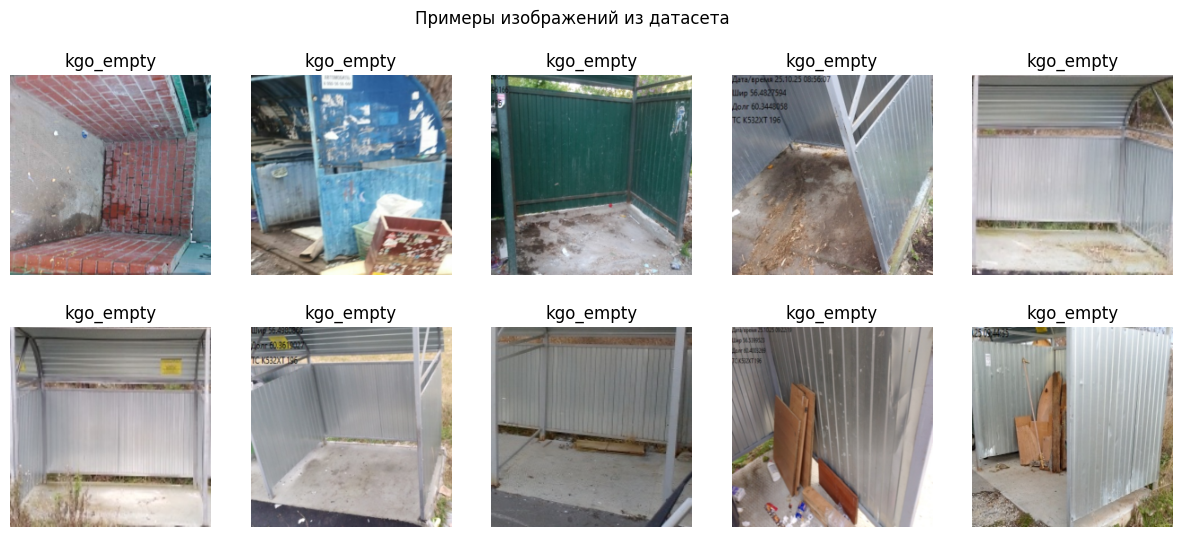

In [ ]:
transform_preview = T.Compose([T.Resize((224,224)), T.ToTensor()])

dataset_preview = datasets.ImageFolder(str(data_dir), transform=transform_preview)
class_names = dataset_preview.classes

fig, axes = plt.subplots(2, 5, figsize=(15,6))
for i in range(10):
    img, label = dataset_preview[i]
    ax = axes[i//5, i%5]
    ax.imshow(img.permute(1,2,0))
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Примеры изображений из датасета')
plt.show()

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(str(data_dir), transform=train_transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

val_ds.dataset.transform = val_transform
test_ds.dataset.transform = val_transform

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1520 | Val: 325 | Test: 327


In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # 2 класса

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [ ]:
early_stop_patience = 3      
early_stop_counter = 0
min_delta = 0.001            

epochs = 30                  
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}


for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
    
    train_loss /= len(train_ds)
    val_loss /= len(val_ds)
    train_acc = train_correct / len(train_ds)
    val_acc = val_correct / len(val_ds)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}", end="")
    
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_resnet_kgo.pth")
        early_stop_counter = 0
        print("Лучшая модель сохранена")
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            break

🚀 Начинаем обучение с Early Stopping...

Epoch  1/30 | Train Loss: 0.4277 Acc: 0.8862 | Val Loss: 0.1914 Acc: 0.9446   → Лучшая модель сохранена
Epoch  2/30 | Train Loss: 0.1339 Acc: 0.9625 | Val Loss: 0.1354 Acc: 0.9446   → Лучшая модель сохранена
Epoch  3/30 | Train Loss: 0.0511 Acc: 0.9875 | Val Loss: 0.1266 Acc: 0.9569   → Лучшая модель сохранена
Epoch  4/30 | Train Loss: 0.0266 Acc: 0.9954 | Val Loss: 0.1338 Acc: 0.9446   → Нет улучшения (1/3)
Epoch  5/30 | Train Loss: 0.0189 Acc: 0.9974 | Val Loss: 0.1248 Acc: 0.9446   → Лучшая модель сохранена
Epoch  6/30 | Train Loss: 0.0098 Acc: 0.9993 | Val Loss: 0.1318 Acc: 0.9508   → Нет улучшения (1/3)
Epoch  7/30 | Train Loss: 0.0057 Acc: 1.0000 | Val Loss: 0.1436 Acc: 0.9538   → Нет улучшения (2/3)
Epoch  8/30 | Train Loss: 0.0028 Acc: 1.0000 | Val Loss: 0.1525 Acc: 0.9446   → Нет улучшения (3/3)

⏹️  Early Stopping сработал после 8 эпох! Переобучение остановлено.

✅ Обучение завершено. Лучшая модель сохранена в best_resnet_kgo.pth


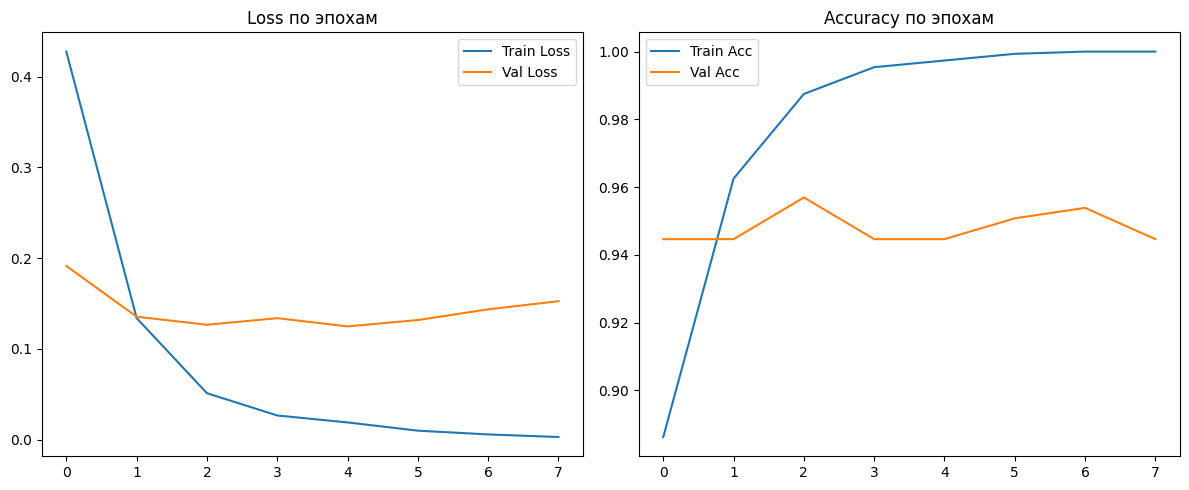

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss по эпохам')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy по эпохам')
plt.legend()

plt.tight_layout()
plt.show()

=== ПОЛНЫЙ ОТЧЁТ ПО ТЕСТОВОМУ ДАТАСЕТУ ===
              precision    recall  f1-score   support

   kgo_empty     0.9079    0.9650    0.9356       143
    kgo_full     0.9714    0.9239    0.9471       184

    accuracy                         0.9419       327
   macro avg     0.9397    0.9445    0.9413       327
weighted avg     0.9436    0.9419    0.9421       327



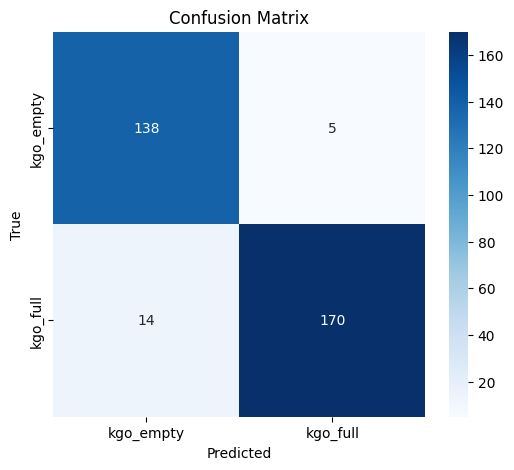


ROC-AUC: 0.9927


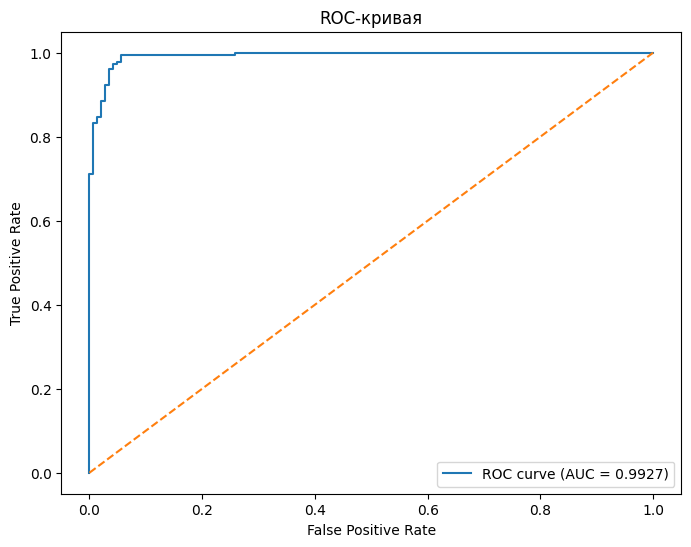

In [ ]:
model.load_state_dict(torch.load("best_resnet_kgo.pth"))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # вероятность класса 1 (full)
        
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

auc = roc_auc_score(all_labels, all_probs)
print(f"\nROC-AUC: {auc:.4f}")

fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

════════════════════════════════════════════════════════════
📸 Изображение: 1234.jpg
🔮 Предсказанный класс: **kgo_full**
🎯 Уверенность модели: 98.6%
   • kgo_empty: 1.4%
   • kgo_full:  98.6%
════════════════════════════════════════════════════════════


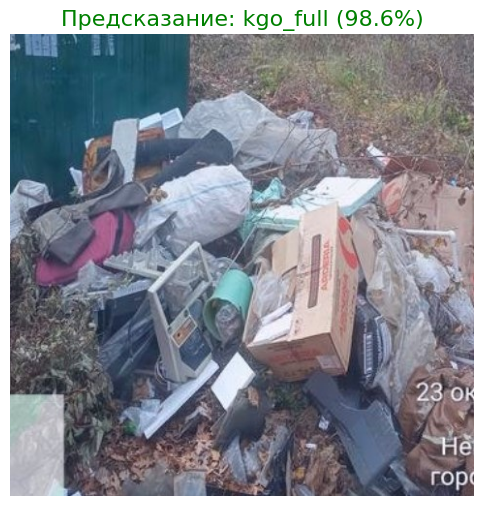

In [ ]:

from PIL import Image
import matplotlib.pyplot as plt

image_path = "1234.jpg"   

model.load_state_dict(torch.load("best_resnet_kgo.pth", map_location=device))
model.eval()

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

img = Image.open(image_path).convert("RGB")
img_tensor = inference_transform(img).unsqueeze(0).to(device) 

with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)[0]                    
    pred_idx = output.argmax(dim=1).item()
    confidence = probs[pred_idx].item()

class_names = ['kgo_empty', 'kgo_full']   

print(f"confidence: {confidence:.1%}")
print(f"   • kgo_empty: {probs[0]:.1%}")
print(f"   • kgo_full:  {probs[1]:.1%}")